<h1 style="color:#ffffff; background-color:#2B3A67; text-align:center; font-weight:bold; padding:16px 10px; border-radius:8px; margin-bottom:6px;">Day 2 — Activations, Forward Propagation &amp; Loss</h1>
<p style="color:#F2C14E; background-color:#3F5185; text-align:center; font-weight:bold; font-style:italic; padding:6px 10px; border-radius:6px; margin-top:0; font-size:15px;">Cardiac Patient Monitoring System — How a Network Turns Inputs Into a Prediction, and Predictions Into a Number to Improve</p>


<a id="toc"></a>
<h2 style="color:#F2C14E; background-color:#3F5185; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">Table of Contents</h2>
<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup — Importing NumPy &amp; Matplotlib</a></li>
<li><a href="#section1">1. Why Activation Functions Matter</a></li>
<li><a href="#section2">2. Common Activation Functions</a></li>
<li><a href="#section3">3. Forward Propagation</a></li>
<li><a href="#section4">4. The Loss Function</a></li>
<li><a href="#section5">5. Common Mistakes to Avoid</a></li>
<li><a href="#section6">6. Quick Reference</a></li>
<li><a href="#section7">7. Hands-On Lab — Activations &amp; the Forward Pass</a></li>
<li><a href="#section8">8. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section9">9. Daily Stand-up</a></li>
<li><a href="#section10">10. Summary — What I Learned Today</a></li>
</ol>
</div>


<a id="section0"></a>
<h2 style="color:#F2C14E; background-color:#3F5185; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">0. Setup — Importing NumPy &amp; Matplotlib</h2>
<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> Yesterday introduced the building blocks of a neural network — neurons, weights, layers. Today answers two questions those pieces raise immediately: what turns a stack of weighted sums into something that can learn curves instead of just straight lines, and how does the network know it made a mistake?
</div>


In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)

NumPy version: 2.3.5


<a id="section1"></a>
<h2 style="color:#F2C14E; background-color:#3F5185; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">1. Why Activation Functions Matter</h2>
Without an activation function, a neural network — no matter how many layers — <b>collapses into a single linear model</b>, because a stack of linear operations is still linear. The activation function introduces <b>non-linearity</b>, which is what lets the network learn complex, curved patterns. It is the single ingredient that makes deep learning powerful.

In [2]:
# A quick proof by example: stacking two "layers" with NO activation function
# is mathematically identical to one single linear layer.
np.random.seed(42)
x = np.random.randn(1, 4)
W1, b1 = np.random.randn(4, 5), np.random.randn(5)
W2, b2 = np.random.randn(5, 3), np.random.randn(3)

# Two linear layers stacked, no activation in between
stacked_output = (x @ W1 + b1) @ W2 + b2

# One equivalent single linear layer
W_combined = W1 @ W2
b_combined = b1 @ W2 + b2
single_layer_output = x @ W_combined + b_combined

print("Two stacked linear layers:", np.round(stacked_output, 4))
print("One combined linear layer:", np.round(single_layer_output, 4))
print("Identical?", np.allclose(stacked_output, single_layer_output))

Two stacked linear layers: [[-0.685  -0.033  -1.9782]]
One combined linear layer: [[-0.685  -0.033  -1.9782]]
Identical? True


<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> Two "layers" with no activation function between them are provably just <b>one</b> layer in disguise — no matter how many you stack, without non-linearity the whole network can only ever learn a straight line (or flat hyperplane). Activation functions are what break this collapse.
</div>


<a id="section2"></a>
<h2 style="color:#F2C14E; background-color:#3F5185; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">2. Common Activation Functions</h2>


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#3F5185; color:#F2C14E;"><th style="padding:8px; text-align:left;">Function</th><th style="padding:8px; text-align:left;">Output Range</th><th style="padding:8px; text-align:left;">Use It For</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">ReLU</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">0 to +∞ (negatives → 0)</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Hidden layers — the default choice, fast and effective</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Sigmoid</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">0 to 1</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Output layer for binary classification (a probability)</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Softmax</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">0 to 1, sums to 1</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Output layer for multi-class classification (class probabilities)</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Tanh</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">-1 to +1</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Hidden layers when zero-centered output helps</td></tr>
</table>
</div>


<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> <b>The practical rule:</b> use <b>ReLU</b> in hidden layers by default, and choose the output activation by the task — <b>sigmoid</b> for binary, <b>softmax</b> typically for multi-class, and <b>none</b> (linear) for regression.
</div>


<a id="section3"></a>
<h2 style="color:#F2C14E; background-color:#3F5185; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">3. Forward Propagation</h2>
Forward propagation is the network making a prediction: data enters the input layer and flows forward, each layer computing its weighted sums and activations, until the output layer produces a prediction. It is the network running "forward" to answer — exactly what happens at prediction time, and the first half of every training step.

In [3]:
# Forward pass, conceptually:
# layer1 = ReLU(dot(X, W1) + b1)
# layer2 = ReLU(dot(layer1, W2) + b2)
# output = sigmoid(dot(layer2, W3) + b3)

print("We will compute a real forward pass by hand in Section 7.")

We will compute a real forward pass by hand in Section 7.


<a id="section4"></a>
<h2 style="color:#F2C14E; background-color:#3F5185; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">4. The Loss Function</h2>
After a forward pass, the <b>loss function</b> measures how wrong the prediction was by comparing it to the true label. A high loss means bad predictions; the entire goal of training is to make the loss as small as possible. The right loss depends on the task:

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#3F5185; color:#F2C14E;"><th style="padding:8px; text-align:left;">Task</th><th style="padding:8px; text-align:left;">Loss Function</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Regression</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Mean Squared Error (MSE)</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Binary classification</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Binary cross-entropy</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Multi-class classification</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Categorical cross-entropy</td></tr>
</table>
</div>


<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> Notice the pattern: the loss function and the output activation are chosen <b>together</b>, as a matched pair, for each task — sigmoid pairs with binary cross-entropy, softmax pairs with categorical cross-entropy, and a linear output pairs with MSE.
</div>


<a id="section5"></a>
<h2 style="color:#F2C14E; background-color:#3F5185; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">5. Common Mistakes to Avoid</h2>
<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> <ul>
<li><b>Stacking layers with no activation function</b> — as shown in Section 1, this collapses into one linear layer, wasting all the extra parameters.</li>
<li><b>Using sigmoid in hidden layers of a deep network</b> — it saturates (flattens) for large inputs, which slows or stalls learning; ReLU is the standard default for hidden layers.</li>
<li><b>Mismatching the output activation and the loss function</b> — e.g. using MSE with a sigmoid output, or softmax with binary cross-entropy; always pair them per the task, as in Section 4.</li>
<li><b>Using softmax by default for binary classification</b> — a single sigmoid output is the standard and simpler choice for binary classification; softmax is typically used for multi-class classification.</li>
<li><b>Confusing the loss value with the metric that matters</b> — a falling loss during training is a good sign, but the model is still judged by task metrics (accuracy, F1, RMSE, etc.), not the raw loss number.</li>
</ul>
</div>


<a id="section6"></a>
<h2 style="color:#F2C14E; background-color:#3F5185; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">6. Quick Reference</h2>


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#3F5185; color:#F2C14E;"><th style="padding:8px; text-align:left;">Task</th><th style="padding:8px; text-align:left;">Formula / Code</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">ReLU</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>np.maximum(0, x)</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Sigmoid</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>1 / (1 + np.exp(-x))</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Tanh</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>np.tanh(x)</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Softmax</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>z = x - np.max(x, axis=-1, keepdims=True); e = np.exp(z); e / np.sum(e, axis=-1, keepdims=True)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Forward pass (one layer)</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>activation(X @ W + b)</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">MSE loss</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>np.mean((y_true - y_pred) ** 2)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Binary cross-entropy</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>-np.mean(y*np.log(p) + (1-y)*np.log(1-p))</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Hidden layer default</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">ReLU</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Output: binary classification</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Sigmoid + binary cross-entropy</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Output: multi-class classification</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Softmax + categorical cross-entropy</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Output: regression</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">None (linear) + MSE</td></tr>
</table>
</div>


<a id="section7"></a>
<h2 style="color:#F2C14E; background-color:#3F5185; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">7. Hands-On Lab — Activations &amp; the Forward Pass</h2>
<div style="border-left:5px solid #9B6FD4; background-color:#f3edfb; padding:10px 15px; margin:10px 0; border-radius:4px; color:#4d3475;">
<b>Goal:</b> Plot the three core activation functions to build intuition for their shape, choose the correct activation and loss function for the Cardiac Patient Monitoring System, then compute one full forward pass by hand for a tiny 2-layer network.
</div>


<h3 style="color:#F2C14E; font-weight:bold; background-color:#2D3748; display:inline-block; padding:4px 10px; border-radius:6px;">Step 1 — Plot ReLU, sigmoid, and tanh over a range of inputs</h3>


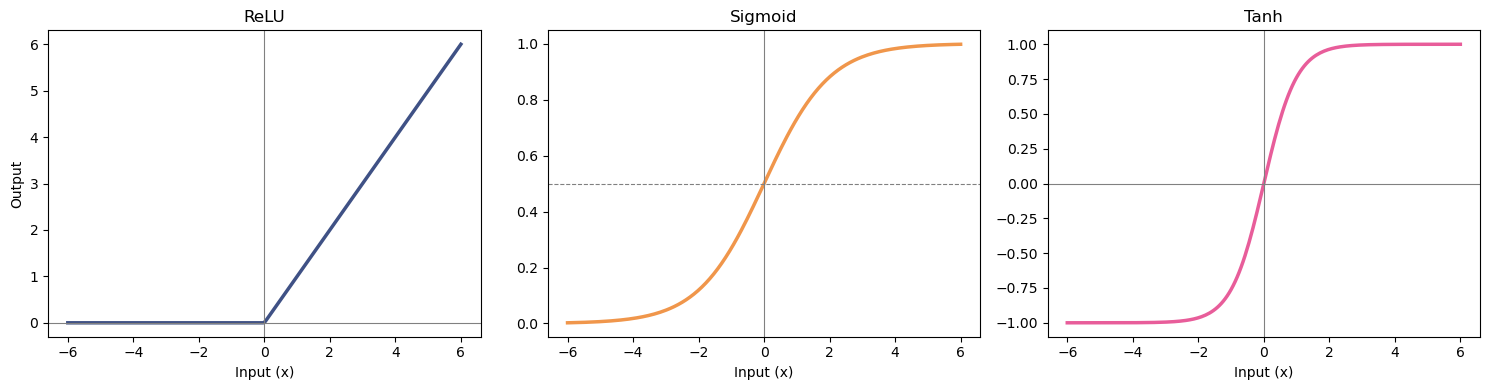

In [4]:
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

x_values = np.linspace(-6, 6, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x_values, relu(x_values), color="#3F5185", linewidth=2.5)
axes[0].set_title("ReLU")
axes[0].axhline(0, color="gray", linewidth=0.8)
axes[0].axvline(0, color="gray", linewidth=0.8)

axes[1].plot(x_values, sigmoid(x_values), color="#F0964B", linewidth=2.5)
axes[1].set_title("Sigmoid")
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[1].axvline(0, color="gray", linewidth=0.8)

axes[2].plot(x_values, tanh(x_values), color="#E85D9A", linewidth=2.5)
axes[2].set_title("Tanh")
axes[2].axhline(0, color="gray", linewidth=0.8)
axes[2].axvline(0, color="gray", linewidth=0.8)

for ax in axes:
    ax.set_xlabel("Input (x)")
axes[0].set_ylabel("Output")
plt.tight_layout()
plt.show()

<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> Notice ReLU is flat at exactly 0 for all negative inputs, then rises in a straight line — cheap to compute and effective in practice. Sigmoid and tanh both <b>saturate</b> (flatten out) for large positive or negative inputs, which is why they are used far less often in hidden layers of deep networks.
</div>


<h3 style="color:#F2C14E; font-weight:bold; background-color:#2D3748; display:inline-block; padding:4px 10px; border-radius:6px;">Step 2 — Choose the correct activation and loss function for the Phase 3 project</h3>


<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Your project:</b> <b>Phase 3 project:</b> Cardiac Patient Monitoring System — predicting <code>HeartDisease</code> (0 or 1) from clinical measurements. This is a <b>binary classification</b> task.

<b>Hidden layers:</b> ReLU — the standard default, fast to compute and avoids the saturation problem shown in Step 1.

<b>Output layer:</b> a single neuron with <b>sigmoid</b> activation, producing a probability between 0 and 1 that the patient has heart disease.

<b>Loss function:</b> <b>binary cross-entropy</b> — the matched pair for a sigmoid output, per the pairing rule from Section 4.
</div>


<h3 style="color:#F2C14E; font-weight:bold; background-color:#2D3748; display:inline-block; padding:4px 10px; border-radius:6px;">Step 3 — Compute one forward pass by hand for a tiny 2-layer network</h3>


In [5]:
# A tiny 2-layer network: 4 input features -> hidden layer of 3 -> single sigmoid output
np.random.seed(42)

# One sample input, standing in for 4 (already-scaled) patient features
X_sample = np.array([[0.5, -1.2, 0.3, 0.8]])

# Layer 1: 4 inputs -> 3 hidden units, ReLU activation
W1 = np.random.randn(4, 3) * 0.5
b1 = np.zeros(3)

# Layer 2 (output): 3 hidden units -> 1 output, sigmoid activation
W2 = np.random.randn(3, 1) * 0.5
b2 = np.zeros(1)

# --- Forward pass ---
z1 = X_sample @ W1 + b1
a1 = relu(z1)
print("Hidden layer pre-activation (z1):", np.round(z1, 4))
print("Hidden layer after ReLU      (a1):", np.round(a1, 4))

z2 = a1 @ W2 + b2
a2 = sigmoid(z2)
print("Output pre-activation (z2):", np.round(z2, 4))
print("Final prediction (a2, probability of heart disease):", np.round(a2, 4))

Hidden layer pre-activation (z1): [[-0.3357  0.0357  0.0457]]
Hidden layer after ReLU      (a1): [[0.     0.0357 0.0457]]
Output pre-activation (z2): [[-0.0735]]
Final prediction (a2, probability of heart disease): [[0.4816]]


In [6]:
# Now pair that prediction with a loss, given a true label for this sample
y_true = np.array([[1]])   # suppose this patient actually does have heart disease

def binary_cross_entropy(y_true, y_pred, eps=1e-9):
    y_pred = np.clip(y_pred, eps, 1 - eps)   # avoid log(0)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

loss = binary_cross_entropy(y_true, a2)
print(f"Predicted probability : {a2[0][0]:.4f}")
print(f"True label            : {y_true[0][0]}")
print(f"Binary cross-entropy loss: {loss:.4f}")

Predicted probability : 0.4816
True label            : 1
Binary cross-entropy loss: 0.7306


<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> A loss this high (or low) makes intuitive sense once you compare the predicted probability to the true label directly above — a prediction far from the true label produces a large loss, and a prediction close to it produces a small one. That gap is exactly what training (Day 3) will learn to shrink.
</div>


<h3 style="color:#F2C14E; font-weight:bold; background-color:#2D3748; display:inline-block; padding:4px 10px; border-radius:6px;">Step 4 — Document the choices and the forward-pass result</h3>


<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> <b>Summary of today's choices for the Phase 3 project:</b> ReLU in hidden layers, a single sigmoid output neuron, and binary cross-entropy as the loss — the standard, matched combination for binary classification. The hand-computed forward pass above produced a predicted probability of heart disease for one sample patient, and a binary cross-entropy loss comparing that prediction to a true label of <code>1</code>. This loss value is meaningless in isolation — its only purpose is to get <b>smaller</b> across training, which Day 3 (backpropagation) makes happen.
</div>


<a id="section8"></a>
<h2 style="color:#F2C14E; background-color:#3F5185; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">8. Best Practices &amp; Reproducibility</h2>
<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> <ul>
<li>Always use a non-linear activation between layers — never stack purely linear layers.</li>
<li>Default to <b>ReLU</b> for hidden layers unless there is a specific reason to choose otherwise.</li>
<li>Always pair the output activation with the matching loss function: sigmoid + binary cross-entropy, softmax + categorical cross-entropy, linear + MSE.</li>
<li>Fix <code>np.random.seed(...)</code> when initializing weights for a worked example, so results are reproducible.</li>
<li>Clip predictions away from exactly 0 or 1 before computing cross-entropy loss, to avoid <code>log(0)</code> errors.</li>
<li>When implementing <b>softmax</b> manually, subtract the row maximum before <code>np.exp(...)</code> to improve numerical stability and normalize along the last axis for batch-safe behavior.</li>
</ul>
</div>


<a id="section9"></a>
<h2 style="color:#F2C14E; background-color:#3F5185; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">9. Daily Stand-up</h2>
<div style="border-left:5px solid #9B6FD4; background-color:#f3edfb; padding:10px 15px; margin:10px 0; border-radius:4px; color:#4d3475;">
<b>Completed:</b> Plotted ReLU, sigmoid, and tanh; selected ReLU + sigmoid + binary cross-entropy for the <b>Cardiac Patient Monitoring System</b>; completed and documented a manual 2-layer forward pass and BCE loss.<br><br>
<b>Next:</b> Day 3 — backpropagation, gradient descent, learning-rate experiments, and preparation for the mentor code/notebook review.<br><br>
<b>Blockers:</b> None identified in today's notebook. Continue watching tensor shapes and numerical stability when moving from NumPy examples to framework code.
</div>


<a id="section10"></a>
<h2 style="color:#F2C14E; background-color:#3F5185; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">10. Summary — What I Learned Today</h2>
<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> <ul>
<li><b>Activation functions</b> introduce non-linearity — without them, any stack of layers collapses into one linear model.</li>
<li><b>ReLU</b> is the default for hidden layers; <b>sigmoid</b>, <b>softmax</b>, and <b>linear</b> outputs are chosen by the task (binary, multi-class, regression).</li>
<li><b>Forward propagation</b> is the network computing a prediction, layer by layer, from input to output.</li>
<li>The <b>loss function</b> measures how wrong that prediction was — MSE for regression, binary or categorical cross-entropy for classification.</li>
<li>Output activation and loss function are chosen as a <b>matched pair</b> per task.</li>
<li>For the Cardiac Patient Monitoring System: ReLU hidden layers, a sigmoid output, and binary cross-entropy loss.</li>
</ul>
</div>
<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> <b>Where this leads next:</b> Day 3 covers backpropagation — how the loss computed today flows backward through the network to actually update the weights, which is what training a neural network means.
</div>
